### ARIMA
This notebook implement different versions of the ARIMA model, for different temporal aggregations. Given the various frequency of the time series, MAPE is used to compare models performances, since it is a scale-independent metric. 
The models try to take advantage of explanatory variables for the predictions. The spatial element is added to these factors in the later models.
The seasonal variations of the ARIMA is also tested.

Main points:
- using different temporal aggregation for predicting demand with ARIMA
- test the influence of different seasonalily with SARIMA

In [1]:
from datetime import datetime
import holidays
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
from statsmodels.graphics import tsaplots 

from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

from pmdarima.metrics import smape
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import seaborn as sns
sns.set_theme(style='white')

import warnings
warnings.filterwarnings("ignore")

In [2]:
# BUILD DATAFRAME 

df = pd.read_parquet('C:/Users/luisa/Desktop/thesis_project/data/tripsv3_augmented.parquet') 
df['date_hour'] = [pd.Timestamp(df.at[i, 'trip_start'].year, df.at[i, 'trip_start'].month, df.at[i, 'trip_start'].day, df.at[i, 'trip_start'].hour) for i in range(len(df))]

# counts
df = df.groupby(['date_hour']).aggregate({'name_day':lambda x:x.to_list()[0], 'leisure':['sum'], 'public_services':['sum'], 'building':['sum'], 
            'education':['sum'], 'food':['sum'], 'transport':['sum'], 'finantial':['sum'], 'healthcare':['sum'], 'office':['sum'], 'shop':['sum'], 'tourism':['sum'], 
            'count_bus_multimodality':['mean'], 'unique_id':['count']}).reset_index()
df.columns = df.columns.droplevel(1)
df.rename(columns = {'unique_id':'trips_count'}, inplace = True)

# IMPORTANT STEP: 
# ADD MISSING TIMESTAMPS

# since freq='H' is the min freq used in this project, use that, then can aggregate times if needed
freq = 'H'
# time interavals
all_times = pd.DataFrame({'date_hour': pd.date_range(df.date_hour.min(), df.date_hour.max(), freq=freq)})
# build dataframe with rows for all times and all cells, even when trips_count = 0 
df_all_times = pd.merge(all_times, df, left_on='date_hour', right_on='date_hour', how='left')

# fill trips count with 0 when there were no trips
df_all_times.trips_count = df_all_times.trips_count.fillna(-1)
# for POIs categories, fill NaN with respective columns median
for col in ['leisure', 'public_services', 'building','education', 'food', 'transport', 'finantial', 'healthcare', 'office', 'shop', 'tourism', 'count_bus_multimodality']:
    md = df_all_times[col].dropna().median()
    df_all_times[col] = df_all_times[col].fillna(md)

# add weather info
weather = pd.read_csv('C:/Users/luisa/Desktop/thesis_project/data/weather_info.csv')
weather = weather[['date_time', 'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'precipMM']]

weather['date_time'] = pd.to_datetime(weather.date_time, format="%Y-%m-%d %H:%M:%S")

df = df_all_times.merge(weather, left_on=['date_hour'], right_on=['date_time'])
df = df.drop(['date_time'], axis=1)


# sort by timestamp
df = df.sort_values(by=['date_hour'])

In [3]:
# FUNCTION TO GROUP WITH DIFFERENT TEMPORAL AGGREGATION
def temporal_aggregation(df, aggr_freq):
       # aggregating multiple fields for each hour
       df = df.resample(aggr_freq, on='date_hour').agg({'leisure':'mean', 'public_services':'mean', 'building':'mean',
              'education':'mean', 'food':'mean', 'transport':'mean', 'finantial':'mean', 'healthcare':'mean', 'office':'mean',
              'shop':'mean', 'tourism':'mean', 'count_bus_multimodality':'mean', 'trips_count':'sum',
              'totalSnow_cm':'mean', 'windspeedKmph':'mean', 'tempC':'mean', 'visibility':'median', 'precipMM':'mean'})

       # add holiday (boolean)
       df['holiday'] = [df.index[i] in holidays.Italy() for i in range(len(df))] 
       df['holiday'] = df.holiday.astype('int').to_numpy() 
       # add weekday as number (0-6)
       df['day'] = df.index.weekday 
       return df

In [4]:
# normalize column-wise train and test (based on train avg and sd)
# return normalized train and test data, and avg and sd used to norm trips_count
def normalize(train, test):
    for col in train.columns.drop(['trips_count']):
        avg = train[col].mean()
        std = train[col].std()
        train[col] = (train[col] - avg) / std
        test[col] = (test[col] - avg) / std
    avg, sd = train.trips_count.mean(), train.trips_count.std()
    train['trips_count'] = (train.trips_count - avg) / sd
    test['trips_count'] = (test.trips_count - avg) / sd
    return train, test, avg, sd

# de-norm trips_cnt
def denorm_cnt(train, test, avg, sd):
    # de-norm
    train.trips_count = (train.trips_count * sd) + avg
    test.trips_count = (test.trips_count * sd) + avg
    return train, test

#### 8H frequency

In [5]:
df8H = temporal_aggregation(df = df, aggr_freq = '8H')

In [6]:
# from 2022-01-01 to 2022-05-04 as test data
# train8H = df8H[df8H.index.year < 2022]
# test8H = df8H[df8H.index.year == 2022]

# only one month for test (last day availanle 2022-05-04):
train8H = df8H[df8H.index < pd.Timestamp('2022-04-04 00:00:00')] 
test8H = df8H[df8H.index >= pd.Timestamp('2022-04-04 00:00:00')]

train8H, test8H, avg, sd = normalize(train8H, test8H)

[auto_arima](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html#pmdarima.arima.auto_arima)

In [7]:
# ARIMA model w/ freq='8H'
ARIMA_model = pm.auto_arima(train8H['trips_count'], # time-serie data to estimate
                    train8H[train8H.columns.drop('trips_count')], # list of exogenous variables to use for prediction (optional)
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None,# order of first-differencing; if None, the value is determined by the model based on the results of the test selected (below: adf aka Augmented Dickey-Fuller))
                    test='adf', # Augmented Dickey-Fuller Test to find optimal 'd' parameter
                    max_p=3, 
                    max_q=3, 
                    m=1, # frequency of series: 1 aka annual (if m==1, seasonal is set to FALSE automatically) -> non-seasonal arima
                    seasonal=False, # standard ARIMA, without seasonality
                    suppress_warnings=True,
                    stepwise=True # use the stepwise algorithm to dentify the optimal model parameters (significantly faster)
                )

In [8]:
ARIMA_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1469
Model:               SARIMAX(3, 0, 3)   Log Likelihood                 -38.730
Date:                Fri, 14 Oct 2022   AIC                            131.460
Time:                        15:34:22   BIC                            274.353
Sample:                    11-30-2020   HQIC                           184.748
                         - 04-03-2022                                         
Covariance Type:                  opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
intercept                   0.0003      0.004      0.082      0.935      -0.007       0.008
leisure                     0.0672      0.007      9.307      0.000       0.053       0.081
public_services             0.0507      0.008      6.387      0.000       0.035       0.066
building                    0.0833      0.007     11.215      0.000       0.069       0.098
education                   0.0647      0.008      8.314      0.000       0.049       0.080
food                        0.0684      0.009      7.653      0.000       0.051       0.086
transport                   0.1989      0.011     17.899      0.000       0.177       0.221
finantial                   0.0407      0.008      5.356      0.000       0.026       0.056
healthcare                  0.0452      0.007      6.122      0.000       0.031       0.060
office                      0.0634      0.008      7.821      0.000       0.048       0.079
shop                        0.1306      0.011     12.248      0.000       0.110       0.152
tourism                     0.0522      0.006      8.281      0.000       0.040       0.065
count_bus_multimodality     0.0094      0.006      1.444      0.149      -0.003       0.022
totalSnow_cm               -0.0128      0.006     -2.050      0.040      -0.025      -0.001
windspeedKmph               0.0067      0.008      0.861      0.389      -0.009       0.022
tempC                       0.0164      0.018      0.906      0.365      -0.019       0.052
visibility                 -0.0038      0.008     -0.506      0.613      -0.019       0.011
precipMM                   -0.0345      0.009     -3.976      0.000      -0.051      -0.017
holiday                    -0.0049      0.008     -0.637      0.524      -0.020       0.010
day                        -0.0202      0.008     -2.670      0.008      -0.035      -0.005
ar.L1                      -0.0071      0.005     -1.356      0.175      -0.017       0.003
ar.L2                      -0.0071      0.006     -1.249      0.212      -0.018       0.004
ar.L3                       0.9825      0.006    167.072      0.000       0.971       0.994
ma.L1                       0.1577      0.019      8.418      0.000       0.121       0.194
ma.L2                       0.1485      0.019      7.859      0.000       0.111       0.186
ma.L3                      -0.7149      0.019    -38.556      0.000      -0.751      -0.679
sigma2                      0.0614      0.002     28.756      0.000       0.057       0.066
===================================================================================
Ljung-Box (L1) (Q):                   5.78   Jarque-Bera (JB):                33.27
Prob(Q):                              0.02   Prob(JB):                         0.00
Heteroskedasticity (H):               1.51   Skew:                             0.11
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.70
=============================================================

In [7]:
# remove not significant explanatory variables
train8H = train8H[train8H.columns.drop(['count_bus_multimodality', 'windspeedKmph', 'tempC', 'visibility', 'holiday'])] 
test8H = test8H[test8H.columns.drop(['count_bus_multimodality', 'windspeedKmph', 'tempC', 'visibility', 'holiday'])]

ARIMA_model = pm.auto_arima(train8H['trips_count'], 
                    train8H[train8H.columns.drop('trips_count')], 
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None, # order of first-differencing; if None, the value is determined with test below
                    test='adf', # Augmented Dickey-Fuller Test 
                    max_p=3, 
                    max_q=3, 
                    m=1, 
                    seasonal=False, 
                    suppress_warnings=True,
                    stepwise=True 
                )

In [8]:
ARIMA_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1469
Model:               SARIMAX(3, 0, 3)   Log Likelihood                 -38.415
Date:                Fri, 14 Oct 2022   AIC                            120.830
Time:                        16:09:34   BIC                            237.261
Sample:                    11-30-2020   HQIC                           164.250
                         - 04-03-2022                                         
Covariance Type:                  opg                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept         3.91e-05      0.004      0.010      0.992      -0.008       0.008
leisure             0.0663      0.007      9.256      0.000       0.052       0.080
public_services     0.0507      0.008      6.439      0.000       0.035       0.066
building            0.0813      0.007     10.954      0.000       0.067       0.096
education           0.0643      0.008      8.312      0.000       0.049       0.079
food                0.0711      0.009      8.038      0.000       0.054       0.088
transport           0.1987      0.011     18.141      0.000       0.177       0.220
finantial           0.0405      0.008      5.352      0.000       0.026       0.055
healthcare          0.0452      0.007      6.168      0.000       0.031       0.060
office              0.0630      0.008      7.897      0.000       0.047       0.079
shop                0.1269      0.011     11.891      0.000       0.106       0.148
tourism             0.0519      0.006      8.315      0.000       0.040       0.064
totalSnow_cm       -0.0145      0.006     -2.342      0.019      -0.027      -0.002
precipMM           -0.0340      0.008     -4.191      0.000      -0.050      -0.018
day                -0.0218      0.007     -2.931      0.003      -0.036      -0.007
ar.L1              -0.0045      0.005     -0.906      0.365      -0.014       0.005
ar.L2              -0.0054      0.005     -0.988      0.323      -0.016       0.005
ar.L3               0.9880      0.005    181.222      0.000       0.977       0.999
ma.L1               0.1608      0.018      8.770      0.000       0.125       0.197
ma.L2               0.1557      0.018      8.459      0.000       0.120       0.192
ma.L3              -0.7083      0.018    -39.165      0.000      -0.744      -0.673
sigma2              0.0616      0.002     29.030      0.000       0.057       0.066
===================================================================================
Ljung-Box (L1) (Q):                   5.82   Jarque-Bera (JB):                34.86
Prob(Q):                              0.02   Prob(JB):                         0.00
Heteroskedasticity (H):               1.51   Skew:                             0.08
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

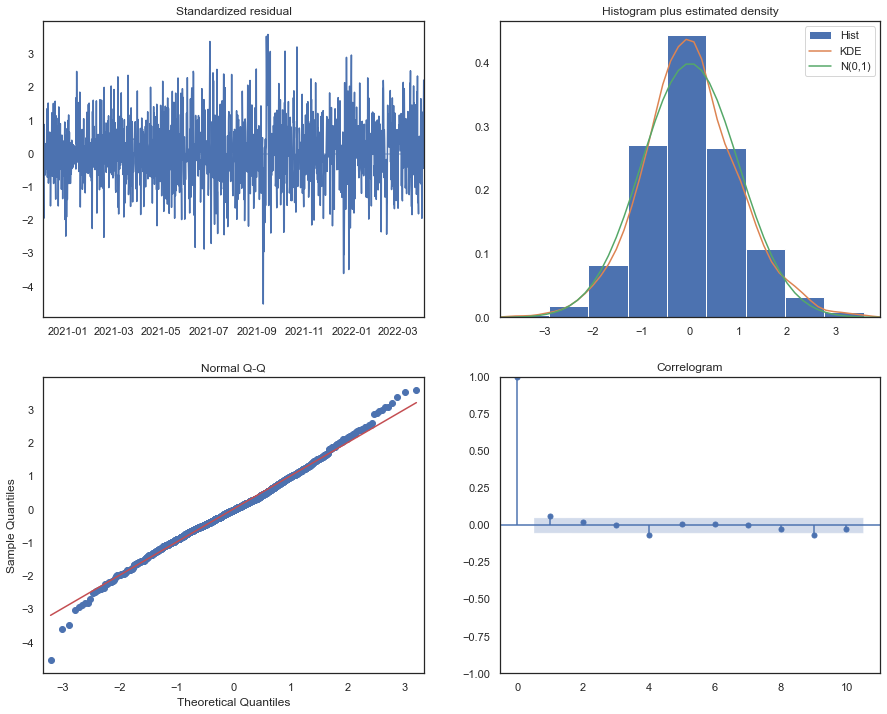

In [9]:
ARIMA_model.plot_diagnostics(figsize=(15,12))
plt.show()

In [10]:
ARIMA_model.params()

intercept          0.000039
leisure            0.066296
public_services    0.050735
building           0.081295
education          0.064257
food               0.071099
transport          0.198708
finantial          0.040517
healthcare         0.045161
office             0.062961
shop               0.126879
tourism            0.051946
totalSnow_cm      -0.014510
precipMM          -0.034046
day               -0.021762
ar.L1             -0.004527
ar.L2             -0.005407
ar.L3              0.988009
ma.L1              0.160801
ma.L2              0.155653
ma.L3             -0.708296
sigma2             0.061552
dtype: float64

In [11]:
def forecast(ARIMA_model, test, train, aggr_freq, trips_cnt_avg, trips_cnt_sd, model_name='ARIMA'):
    # Forecast
    n_periods = len(test)
    fitted, confint = ARIMA_model.predict(n_periods = n_periods, X = test[test.columns.drop('trips_count')], return_conf_int = True) # X -> exogenous variables
    index_of_fc = pd.date_range(test.index[0], periods = n_periods, freq=aggr_freq) # freq='H' --> pred. per hour # + pd.DateOffset(hour=aggr_freq)

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    # confidence interval
    lower_series = pd.Series(confint[:, 0], index=index_of_fc) # lower bound conf. int.
    upper_series = pd.Series(confint[:, 1], index=index_of_fc) # upper bound conf. int.

    # print errors on norm-data
    print('Error on normalized data:')
    print({ 'MSE': mean_squared_error(test.trips_count, fitted_series), 
            'MAE': mean_absolute_error(test.trips_count, fitted_series), 
            'MAPE': mean_absolute_percentage_error(test.trips_count, fitted_series),
            'SMAPE' : smape(test.trips_count, fitted_series) }, '\n')

    # de-norm
    fitted_series = ( fitted_series * trips_cnt_sd ) + trips_cnt_avg
    train, test = denorm_cnt(train, test, avg, sd)
    lower_series = ( lower_series * trips_cnt_sd ) + trips_cnt_avg
    upper_series = ( upper_series * trips_cnt_sd ) + trips_cnt_avg

    # print errors on norm-data
    print('Error on original data:')
    print({ 'MSE': mean_squared_error(test.trips_count, fitted_series), 
            'MAE': mean_absolute_error(test.trips_count, fitted_series), 
            'MAPE': mean_absolute_percentage_error(test.trips_count, fitted_series),
            'SMAPE' : smape(test.trips_count, fitted_series) })

    
    # Plot
    plt.figure(figsize=(15,7))
    plt.plot(train.trips_count, color='#1f76b4', label='Training Set')
    plt.plot(fitted_series, color='darkgreen', label='Predicted Value')

    plt.plot(test.trips_count, color='green', alpha=0.3, label='Actual Test Value')

    plt.fill_between(lower_series.index, 
                    lower_series, 
                    upper_series, 
                    color='k', alpha=.15)
    plt.legend(loc='upper left', labelcolor='linecolor')
    plt.title(model_name+" Forecasting")
    plt.show()

    # Plot with rolling mean
    plt.figure(figsize=(15,7))
    plt.plot(train.trips_count.rolling(window=12).mean(), color='#1f76b4', label='Training Set')
    plt.plot(fitted_series.rolling(window=12).mean(), color='darkgreen', label='Predicted Value')

    plt.plot(test.trips_count.rolling(window=12).mean(), color='green', alpha=0.2, label='Actual Test Value')

    plt.fill_between(lower_series.index, 
                    lower_series, 
                    upper_series, 
                    color='k', alpha=.15)
    plt.legend(loc='upper left', labelcolor='linecolor')
    plt.title(model_name+" Forecasting")
    plt.show()

    # ZOOM ON PREDICTED VS TRUE VALUES
    rcParams["figure.figsize"] = 17, 6
    
    plt.plot(test.trips_count.rolling(window=12).mean(), color='orange', label='Actual Values', alpha=0.5)
    plt.plot(fitted_series.rolling(window=12).mean(), color='green', label='Predicted Values', alpha=0.9)
    plt.legend(loc='upper left', labelcolor='linecolor')
    plt.title(model_name+" Forecasting - Rolling Mean")
    plt.show()

    plt.plot(test.trips_count, color='orange', label='Actual Values', alpha=0.5)
    plt.plot(fitted_series, color='green', label='Predicted Values', alpha=0.9)
    plt.legend(loc='upper left', labelcolor='linecolor')
    plt.title(model_name+" Forecasting")
    plt.show()

    return fitted_series

Error on normalized data:
{'MSE': 0.1293475387635087, 'MAE': 0.30571271140926204, 'MAPE': 1.9989192055625333, 'SMAPE': 56.93516697159433} 

Error on original data:
{'MSE': 209.19357317154729, 'MAE': 12.294435170850992, 'MAPE': 0.1941292879840476, 'SMAPE': 20.243935390849852}


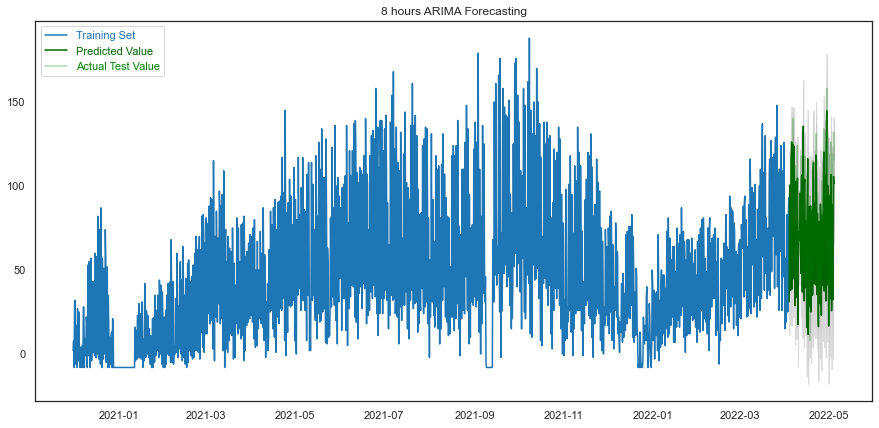

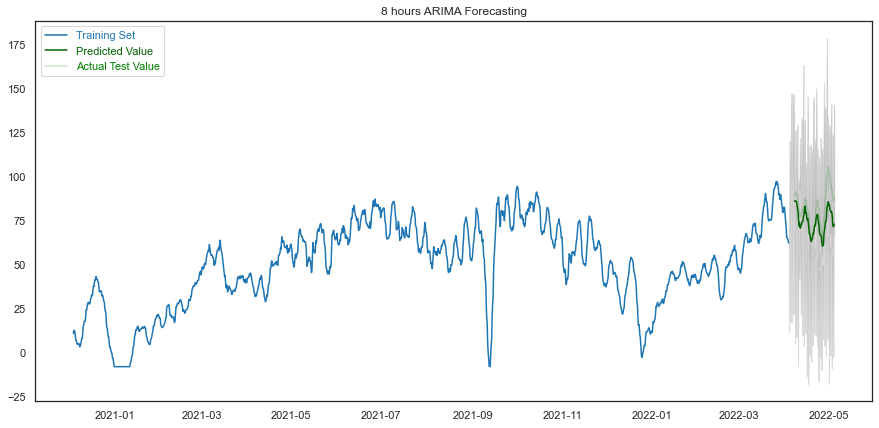

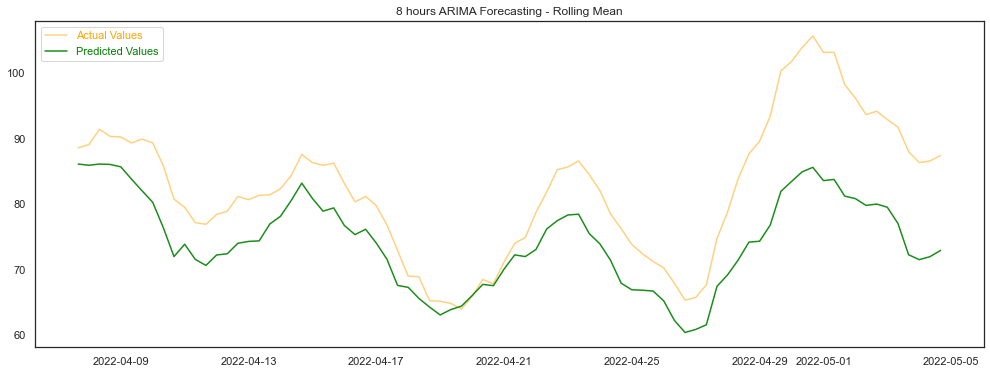

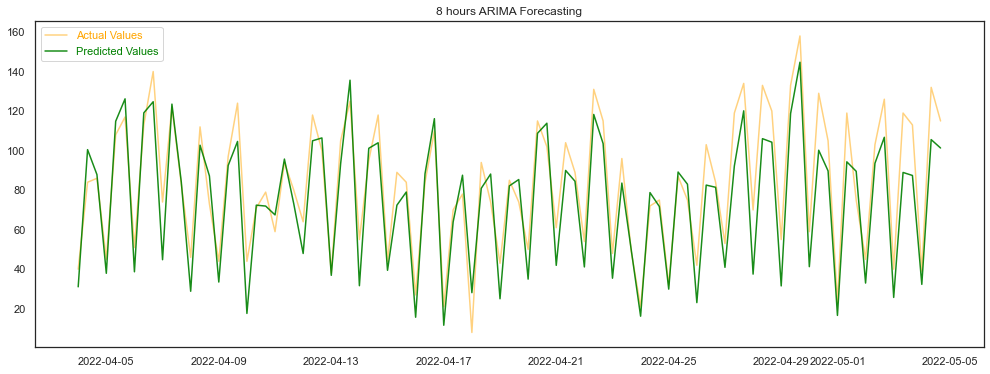

In [12]:
fitted_series = forecast(ARIMA_model, test8H, train8H, '8H', avg, sd, model_name='8 hours ARIMA')

In [13]:
fitted_series

2022-04-04 00:00:00     31.092151
2022-04-04 08:00:00    100.496446
2022-04-04 16:00:00     87.871257
2022-04-05 00:00:00     37.932042
2022-04-05 08:00:00    114.853416
                          ...    
2022-05-03 08:00:00     88.955033
2022-05-03 16:00:00     87.426762
2022-05-04 00:00:00     32.332228
2022-05-04 08:00:00    105.566620
2022-05-04 16:00:00    101.321151
Freq: 8H, Length: 93, dtype: float64

In [14]:
# Mean Absolute Percentage Error
mape = np.mean(np.abs(fitted_series - test8H.trips_count)/np.abs(test8H.trips_count))
# Correlation
corr = np.corrcoef(fitted_series, test8H.trips_count)[0,1]  
# Min-Max Error
mins = np.amin(np.hstack([fitted_series[:,None], test8H.trips_count[:,None]]), axis=1)
maxs = np.amax(np.hstack([fitted_series[:,None], test8H.trips_count[:,None]]), axis=1)
minmax = 1 - np.mean(mins/maxs)

print('Mean Absolute Percentage Error:', mape, '\nCorrelation:', corr, '\nMin-Max Error:', minmax)

Mean Absolute Percentage Error: 0.1941292879840477 
Correlation: 0.9350777733438441 
Min-Max Error: 0.17214976343738098


In [15]:
# pmdarima library implemented only the metric not present in sklearn, thus only the SMAPE (Symmetric Mean Absolute Percentage Error)
# a perfect SMAPE score is 0.0, and a higher score indicates a higher error rate
# https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.metrics.smape.html#pmdarima.metrics.smape
print('Symmetric Mean Absolute Percentage Error:', smape(test8H.trips_count, fitted_series))

Symmetric Mean Absolute Percentage Error: 20.243935390849852


In [16]:
mse = 0
for i, j in zip(test8H.trips_count, fitted_series):
    mse += (i - j)**2
mse = mse / len(test8H.trips_count)
mse

209.1935731715473

In [17]:
metrics8H = { 'MSE': mean_squared_error(test8H.trips_count, fitted_series), 
'MAE': mean_absolute_error(test8H.trips_count, fitted_series), 
'MAPE': mean_absolute_percentage_error(test8H.trips_count, fitted_series),
'SMAPE' : smape(test8H.trips_count, fitted_series) }
metrics8H

{'MSE': 209.19357317154729,
 'MAE': 12.294435170850992,
 'MAPE': 0.1941292879840476,
 'SMAPE': 20.243935390849852}

#### 1H frequency

In [22]:
# aggreated dataframe
dfH = temporal_aggregation(df = df, aggr_freq = 'H')
# remove unsignificant predictor (obatined from summary of ARIMA_model_H)
dfH = dfH[dfH.columns.drop(['totalSnow_cm', 'holiday', 'day', 'precipMM'])]
# split train-test
trainH = dfH[dfH.index < pd.Timestamp('2022-04-04 00:00:00')] # only one month for test (last day availanle 2022-05-04)
testH = dfH[dfH.index >= pd.Timestamp('2022-04-04 00:00:00')]
# normalize data
trainH, testH, avg, sd = normalize(trainH, testH)
# ARIMA model w/ freq='H'
ARIMA_model_H = pm.auto_arima(trainH['trips_count'], # time-serie data to estimate
                    trainH[trainH.columns.drop('trips_count')], # list of exogenous variables to use for prediction (optional)
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None,# order of first-differencing; if None, the value is determined by the model based on the results of the test selected (below: adf aka Augmented Dickey-Fuller))
                    test='adf', # Augmented Dickey-Fuller Test to find optimal 'd' parameter
                    max_p=3, 
                    max_q=3, 
                    m=1, # frequency of series: 1 aka annual (if m==1, seasonal is set to FALSE automatically) -> non-seasonal arima
                    seasonal=False, # standard ARIMA, without seasonality
                    suppress_warnings=True,
                    information_criterion='aic', 
                    stepwise=True # use the stepwise algorithm to dentify the optimal model parameters (significantly faster)
                )

In [23]:
ARIMA_model_H.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                11745
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -6893.823
Date:                Fri, 14 Oct 2022   AIC                          13823.646
Time:                        16:20:20   BIC                          13956.327
Sample:                    11-30-2020   HQIC                         13868.201
                         - 04-03-2022                                         
Covariance Type:                  opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
leisure                     0.0605      0.003     20.410      0.000       0.055       0.066
public_services             0.0476      0.003     14.555      0.000       0.041       0.054
building                    0.1024      0.003     30.195      0.000       0.096       0.109
education                   0.0795      0.003     24.143      0.000       0.073       0.086
food                        0.0883      0.004     24.025      0.000       0.081       0.096
transport                   0.2122      0.004     54.613      0.000       0.205       0.220
finantial                   0.0308      0.003     10.034      0.000       0.025       0.037
healthcare                  0.0531      0.003     18.632      0.000       0.048       0.059
office                      0.0636      0.003     20.142      0.000       0.057       0.070
shop                        0.1175      0.004     30.969      0.000       0.110       0.125
tourism                     0.0500      0.003     19.493      0.000       0.045       0.055
count_bus_multimodality     0.0105      0.004      2.808      0.005       0.003       0.018
windspeedKmph               0.1050      0.009     11.458      0.000       0.087       0.123
tempC                       0.1644      0.013     12.372      0.000       0.138       0.190
visibility                  0.0434      0.010      4.508      0.000       0.025       0.062
ar.L1                       0.5362      0.008     66.999      0.000       0.521       0.552
ar.L2                       0.1865      0.008     24.105      0.000       0.171       0.202
sigma2                      0.1894      0.002     92.669      0.000       0.185       0.193
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1241.10
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.43   Skew:                             0.48
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.28
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Error on normalized data:
{'MSE': 0.43497154141413796, 'MAE': 0.5064083144754343, 'MAPE': 1.006068388284885, 'SMAPE': 89.49662934824936} 

Error on original data:
{'MSE': 23.72110202969101, 'MAE': 3.7397092323073644, 'MAPE': 0.5789753729023945, 'SMAPE': 50.205282926404344}


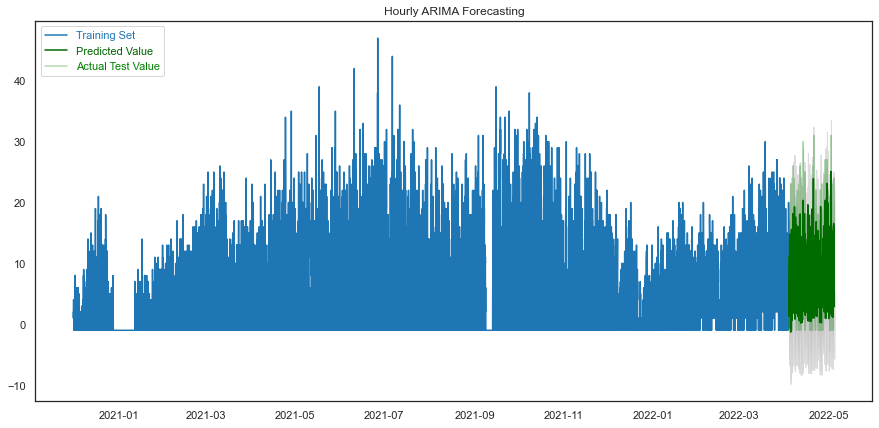

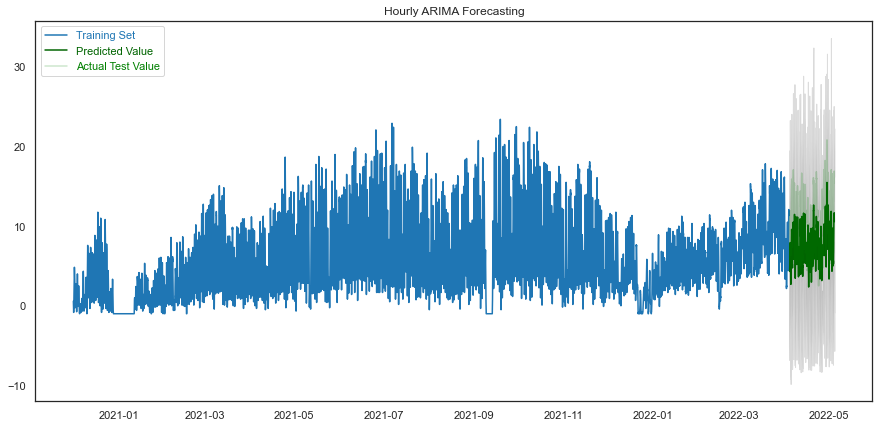

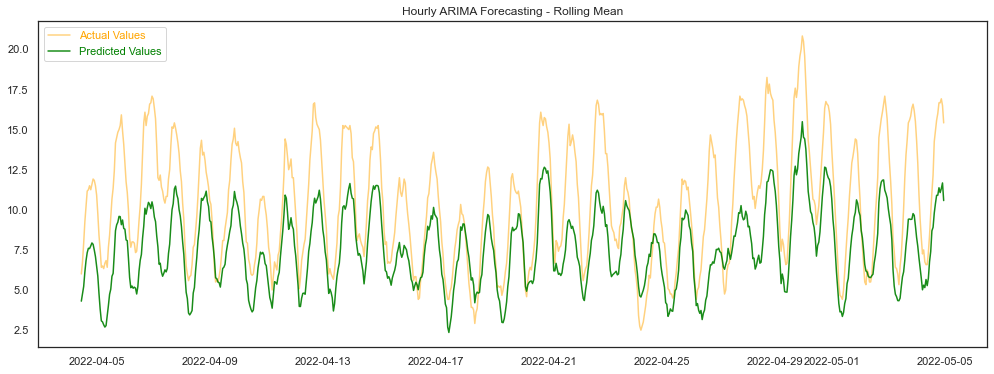

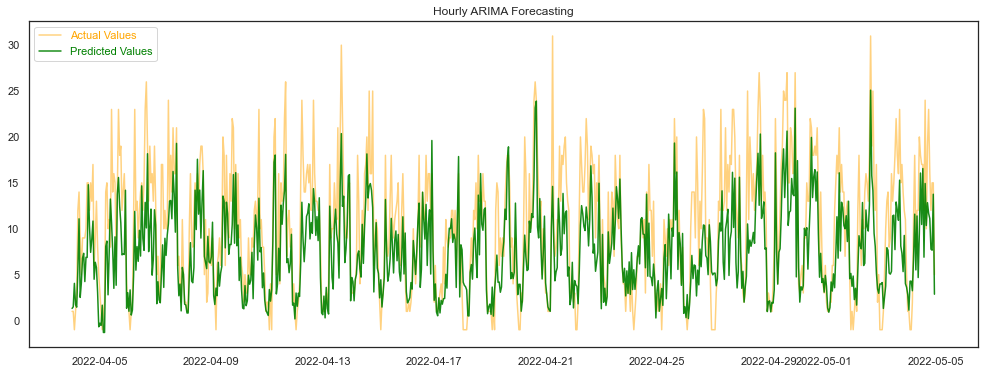

In [24]:
fitted_series = forecast(ARIMA_model_H, testH, trainH, 'H', avg, sd, model_name='Hourly ARIMA')

In [25]:
metricsH = { 'MSE' : mean_squared_error(testH.trips_count, fitted_series), 
'MAE' : mean_absolute_error(testH.trips_count, fitted_series), 
'MAPE' : mean_absolute_percentage_error(testH.trips_count, fitted_series), 
'SMAPE' : smape(testH.trips_count, fitted_series) }
metricsH

{'MSE': 23.72110202969101,
 'MAE': 3.7397092323073644,
 'MAPE': 0.5789753729023945,
 'SMAPE': 50.205282926404344}

#### 4H intervals

In [28]:
# aggreated dataframe
df4H = temporal_aggregation(df = df, aggr_freq = '4H')
# remove unsignificant predictor (obatined from summary of ARIMA_model_4H)
df4H = df4H[df4H.columns.drop(['totalSnow_cm', 'visibility', 'precipMM', 'holiday', 'day'])]
# split train-test
train4H = df4H[df4H.index < pd.Timestamp('2022-04-04 00:00:00')] # only one month for test (last day availanle 2022-05-04)
test4H = df4H[df4H.index >= pd.Timestamp('2022-04-04 00:00:00')]
# normalize
train4H, test4H, avg, sd = normalize(train4H, test4H)
# train4H = df4H[df4H.index.year < 2022]
# test4H = df4H[df4H.index.year == 2022] 
# ARIMA model w/ freq='4H'
ARIMA_model_4H = pm.auto_arima(train4H['trips_count'], # time-serie data to estimate
                    train4H[train4H.columns.drop('trips_count')], # list of exogenous variables to use for prediction (optional)
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None,# order of first-differencing; if None, the value is determined by the model based on the results of the test selected (below: adf aka Augmented Dickey-Fuller))
                    test='adf', # Augmented Dickey-Fuller Test to find optimal 'd' parameter
                    max_p=3, 
                    max_q=3, 
                    m=1, # frequency of series: 1 aka annual (if m==1, seasonal is set to FALSE automatically) -> non-seasonal arima
                    seasonal=False, # standard ARIMA, without seasonality
                    suppress_warnings=True,
                    stepwise=True # use the stepwise algorithm to dentify the optimal model parameters (significantly faster)
                )

In [29]:
ARIMA_model_4H.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2937
Model:               SARIMAX(1, 0, 3)   Log Likelihood               -1131.982
Date:                Fri, 14 Oct 2022   AIC                           2301.963
Time:                        16:25:25   BIC                           2415.681
Sample:                    11-30-2020   HQIC                          2342.911
                         - 04-03-2022                                         
Covariance Type:                  opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
leisure                     0.1008      0.007     15.130      0.000       0.088       0.114
public_services             0.0824      0.007     12.399      0.000       0.069       0.095
building                    0.1599      0.007     23.171      0.000       0.146       0.173
education                   0.1272      0.007     19.074      0.000       0.114       0.140
food                        0.0937      0.008     11.651      0.000       0.078       0.109
transport                   0.1930      0.010     19.876      0.000       0.174       0.212
finantial                   0.0653      0.007      9.134      0.000       0.051       0.079
healthcare                  0.0908      0.007     13.463      0.000       0.078       0.104
office                      0.1135      0.007     15.690      0.000       0.099       0.128
shop                        0.1202      0.009     13.404      0.000       0.103       0.138
tourism                     0.0852      0.006     14.328      0.000       0.074       0.097
count_bus_multimodality     0.0316      0.007      4.678      0.000       0.018       0.045
windspeedKmph               0.0405      0.007      5.439      0.000       0.026       0.055
tempC                       0.1062      0.015      7.195      0.000       0.077       0.135
ar.L1                       0.9973      0.002    604.027      0.000       0.994       1.001
ma.L1                      -0.8966      0.018    -49.758      0.000      -0.932      -0.861
ma.L2                      -0.2515      0.023    -11.061      0.000      -0.296      -0.207
ma.L3                       0.1870      0.018     10.351      0.000       0.152       0.222
sigma2                      0.1264      0.003     36.611      0.000       0.120       0.133
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                87.24
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               1.21   Skew:                             0.37
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.40
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Error on normalized data:
{'MSE': 0.13524650342138025, 'MAE': 0.28876781791648404, 'MAPE': 1.359897138149597, 'SMAPE': 54.13143395035892} 

Error on original data:
{'MSE': 92.76039743517622, 'MAE': 7.5625292690289365, 'MAPE': 1089784138673477.9, 'SMAPE': 26.935052621221214}


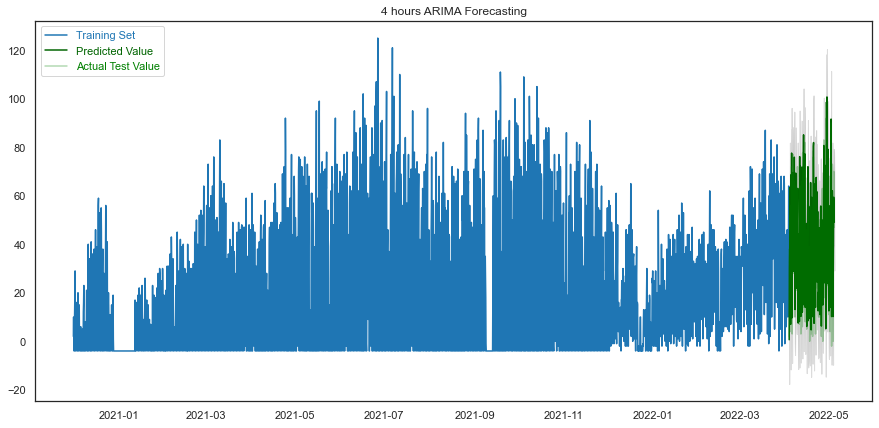

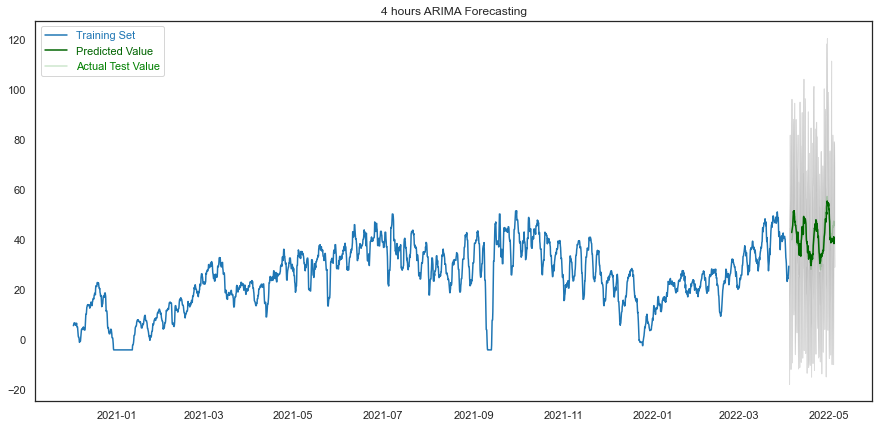

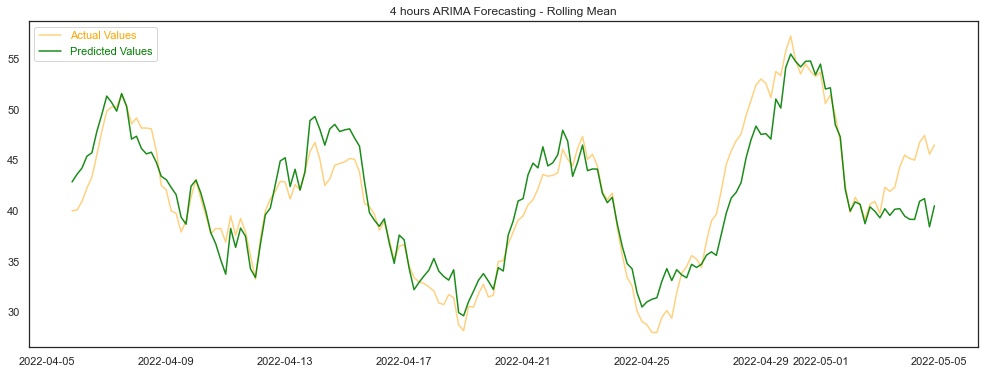

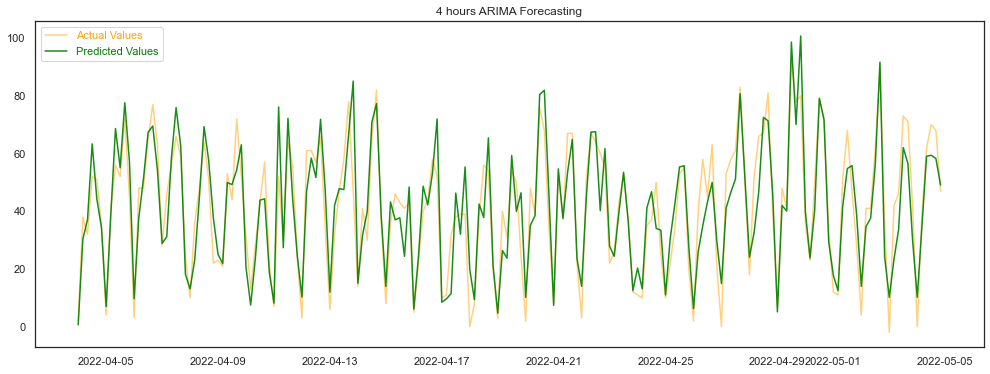

In [30]:
fitted_series = forecast(ARIMA_model_4H, test4H, train4H, '4H', avg, sd, model_name='4 hours ARIMA')

In [31]:
metrics4H = { 'MSE' : mean_squared_error(test4H.trips_count, fitted_series), 
'MAE' : mean_absolute_error(test4H.trips_count, fitted_series), 
'MAPE' : mean_absolute_percentage_error(test4H.trips_count, fitted_series), 
'SMAPE' : smape(test4H.trips_count, fitted_series) }
metrics4H

{'MSE': 92.76039743517622,
 'MAE': 7.5625292690289365,
 'MAPE': 1089784138673477.9,
 'SMAPE': 26.935052621221214}

#### daily aggregation

In [38]:
# aggreated dataframe
dfdaily = temporal_aggregation(df = df, aggr_freq = 'D')
# remove unsignificant predictor (obatined from summary of ARIMA_model_daily)
dfdaily = dfdaily[dfdaily.columns.drop(['count_bus_multimodality', 'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'precipMM', 'holiday', 'day'])]
# split train-test
train_daily = dfdaily[dfdaily.index < pd.Timestamp('2022-04-04 00:00:00')] # one month only for test
test_daily = dfdaily[dfdaily.index >= pd.Timestamp('2022-04-04 00:00:00')]
# normalize
train_daily, test_daily, avg, sd = normalize(train_daily, test_daily)
# ARIMA model w/ freq='D'
ARIMA_model_daily = pm.auto_arima(train_daily['trips_count'], # time-serie data to estimate
                    train_daily[train_daily.columns.drop('trips_count')], # list of exogenous variables to use for prediction (optional)
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None,# order of first-differencing; if None, the value is determined by the model based on the results of the test selected (below: adf aka Augmented Dickey-Fuller))
                    test='adf', # Augmented Dickey-Fuller Test to find optimal 'd' parameter
                    max_p=3, 
                    max_q=3, 
                    m=1, # frequency of series: 1 aka annual (if m==1, seasonal is set to FALSE automatically) -> non-seasonal arima
                    seasonal=False, # standard ARIMA, without seasonality
                    suppress_warnings=True,
                    stepwise=True # use the stepwise algorithm to dentify the optimal model parameters (significantly faster)
                )

In [35]:
ARIMA_model_daily.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  490
Model:               SARIMAX(3, 0, 1)   Log Likelihood                 -31.381
Date:                Fri, 14 Oct 2022   AIC                             94.762
Time:                        16:27:37   BIC                            161.873
Sample:                    11-30-2020   HQIC                           121.119
                         - 04-03-2022                                         
Covariance Type:                  opg                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
leisure             0.0881      0.016      5.560      0.000       0.057       0.119
public_services     0.0489      0.017      2.910      0.004       0.016       0.082
building            0.1138      0.014      8.134      0.000       0.086       0.141
education           0.1003      0.016      6.443      0.000       0.070       0.131
food                0.0899      0.022      4.012      0.000       0.046       0.134
transport           0.2450      0.024     10.181      0.000       0.198       0.292
finantial           0.0442      0.014      3.213      0.001       0.017       0.071
healthcare          0.0716      0.015      4.647      0.000       0.041       0.102
office              0.0756      0.016      4.646      0.000       0.044       0.107
shop                0.1123      0.024      4.674      0.000       0.065       0.159
tourism             0.0712      0.014      5.115      0.000       0.044       0.099
ar.L1               1.1915      0.056     21.172      0.000       1.081       1.302
ar.L2              -0.0324      0.062     -0.518      0.604      -0.155       0.090
ar.L3              -0.1640      0.050     -3.295      0.001      -0.262      -0.066
ma.L1              -0.8831      0.038    -23.271      0.000      -0.957      -0.809
sigma2              0.0664      0.004     15.832      0.000       0.058       0.075
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                14.67
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):               2.06   Skew:                            -0.19
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Error on normalized data:
{'MSE': 0.09564967306930292, 'MAE': 0.26304075299818347, 'MAPE': 0.2627280990311749, 'SMAPE': 30.062850626532992} 

Error on original data:
{'MSE': 611.9442780646802, 'MAE': 21.03958810310741, 'MAPE': 0.08415545871038504, 'SMAPE': 8.798273585133655}


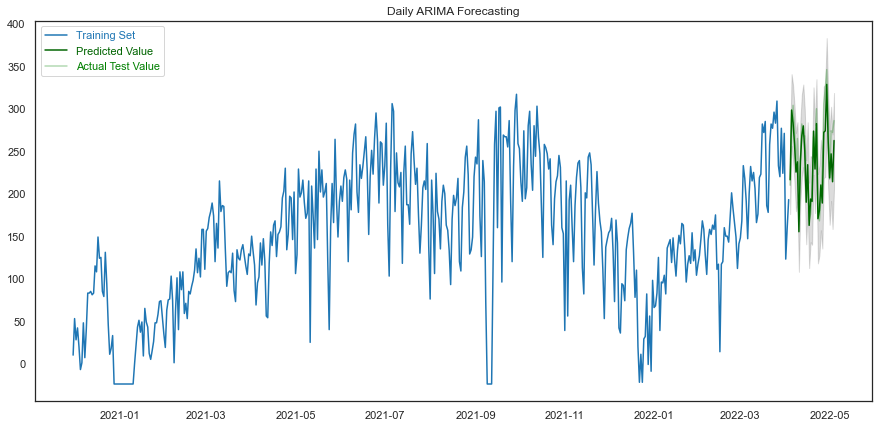

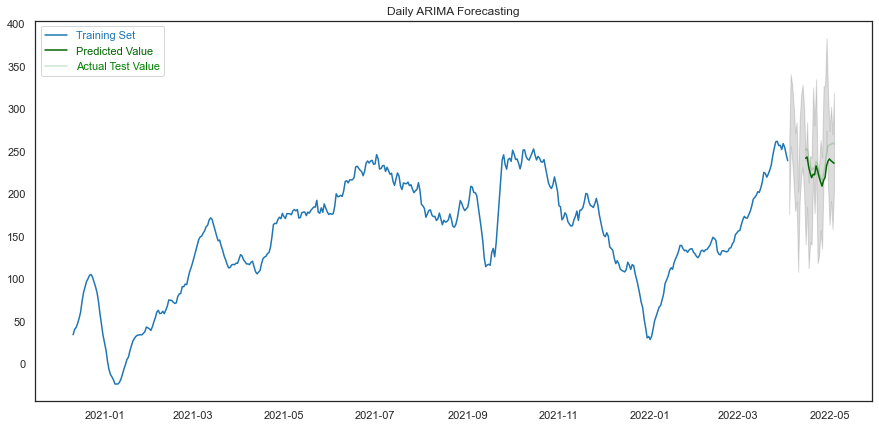

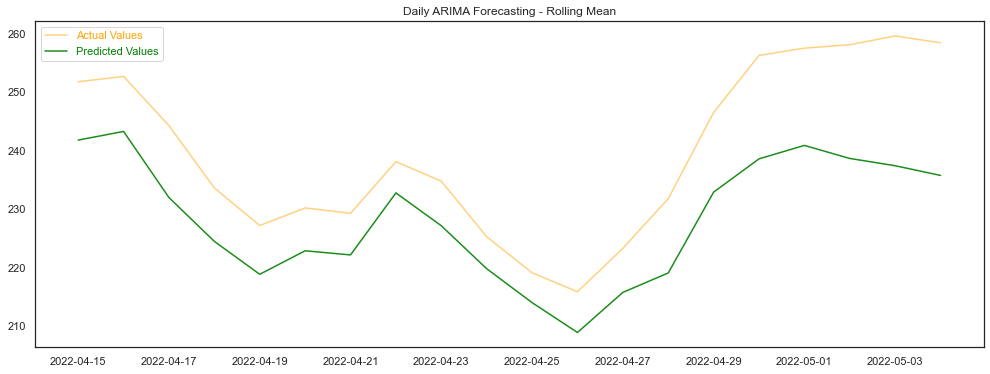

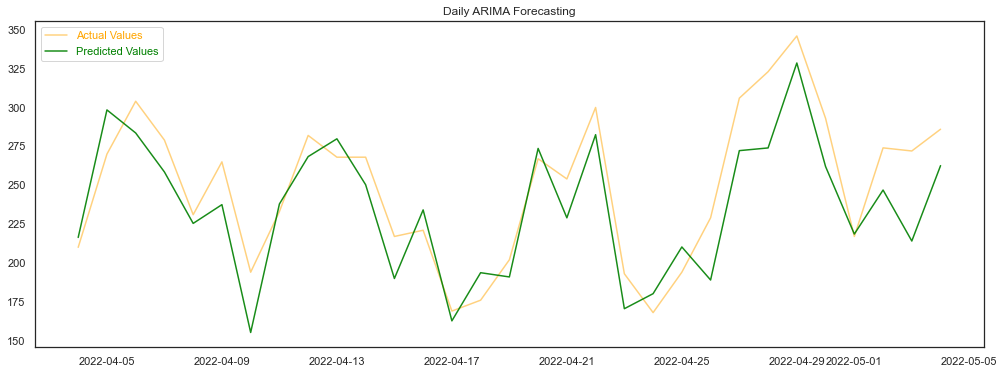

In [39]:
fitted_series = forecast(ARIMA_model_daily, test_daily, train_daily, 'D', avg, sd, model_name='Daily ARIMA')

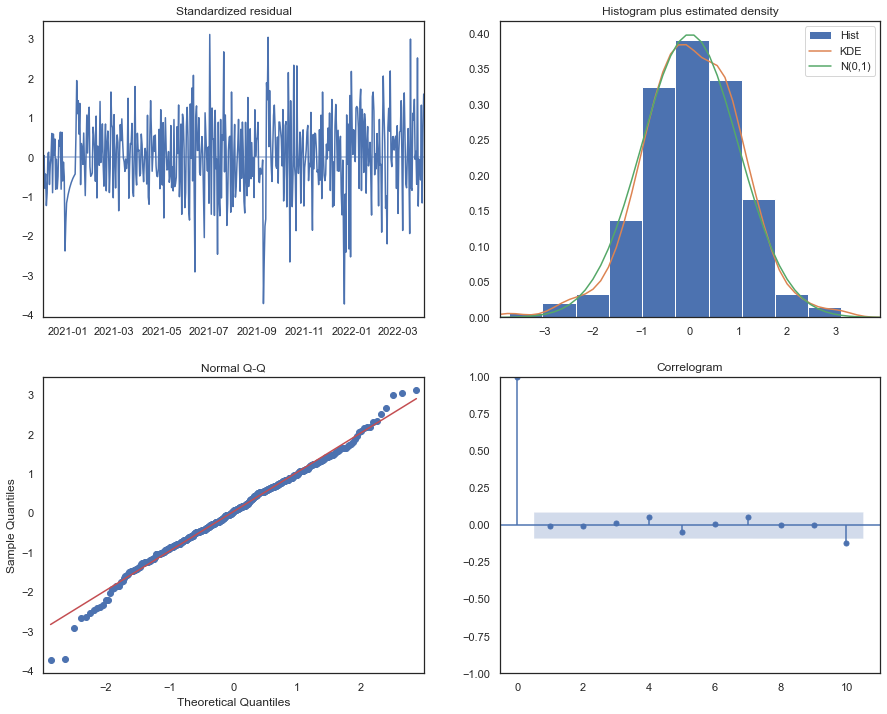

In [40]:
ARIMA_model_daily.plot_diagnostics(figsize=(15,12))
plt.show()

In [41]:
metrics_daily = { 'MSE' : mean_squared_error(test_daily.trips_count, fitted_series), 
'MAE' : mean_absolute_error(test_daily.trips_count, fitted_series), 
'MAPE' : mean_absolute_percentage_error(test_daily.trips_count, fitted_series), 
'SMAPE' : smape(test_daily.trips_count, fitted_series) }
metrics_daily

{'MSE': 611.9442780646802,
 'MAE': 21.03958810310741,
 'MAPE': 0.08415545871038504,
 'SMAPE': 8.798273585133655}

#### Seasonal ARIMA

Monthly seasonality

In [42]:
df8H = temporal_aggregation(df = df, aggr_freq = '8H')
# select only data of 2022 for computational reasons
df8H = df8H[df8H.index.year == 2022]
# drop column non-significant according to SARIMA_model summary
df8H = df8H.drop(['count_bus_multimodality', 'totalSnow_cm', 'windspeedKmph', 'tempC', 'precipMM', 'holiday'], axis=1)
# split train-test
train8H = df8H[df8H.index < pd.Timestamp('2022-04-04 00:00:00')] # only one month for test (last day availanle 2022-05-04)
test8H = df8H[df8H.index >= pd.Timestamp('2022-04-04 00:00:00')]
# normalize
train8H, test8H, avg, sd = normalize(train8H, test8H)

# model
# with seasonality=True & m = 12 --> the m parameter relates to the number of observations per seasonal cycle

# MONTHLY CYCLE
aggr_freq = 8 # 8H
monthly_m = int((24/aggr_freq) * 30) # -> num observation per month

SARIMA_model_M = pm.auto_arima(train8H['trips_count'], 
                    train8H[train8H.columns.drop('trips_count')], 
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None, # order of first-differencing; if None, the value is determined with test below
                    test='adf', # Augmented Dickey-Fuller Test 
                    max_p=3, 
                    max_q=3, 
                    m=monthly_m, 
                    seasonal=True, # SEASONAL VARIATION
                    suppress_warnings=True,
                    stepwise=True 
                )

In [43]:
SARIMA_model_M.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                SARIMAX Results                                 
================================================================================
Dep. Variable:                        y   No. Observations:                  279
Model:             SARIMAX(1, 0, 0, 90)   Log Likelihood                -131.292
Date:                  Fri, 14 Oct 2022   AIC                            292.585
Time:                          17:12:10   BIC                            347.053
Sample:                      01-01-2022   HQIC                           314.434
                           - 04-03-2022                                         
Covariance Type:                    opg                                         
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
leisure             0.0915      0.024      3.771      0.000       0.044       0.139
public_services     0.0673      0.027      2.538      0.011       0.015       0.119
building            0.0814      0.030      2.738      0.006       0.023       0.140
education           0.1067      0.032      3.296      0.001       0.043       0.170
food                0.1137      0.033      3.463      0.001       0.049       0.178
transport           0.3316      0.038      8.839      0.000       0.258       0.405
finantial           0.0801      0.031      2.593      0.010       0.020       0.141
healthcare          0.0762      0.025      3.006      0.003       0.027       0.126
office              0.1276      0.029      4.414      0.000       0.071       0.184
shop                0.1318      0.034      3.844      0.000       0.065       0.199
tourism             0.1046      0.022      4.722      0.000       0.061       0.148
visibility         -0.0318      0.020     -1.614      0.106      -0.070       0.007
day                 0.0647      0.023      2.821      0.005       0.020       0.110
ar.S.L90            0.3450      0.080      4.293      0.000       0.187       0.502
sigma2              0.1440      0.015      9.751      0.000       0.115       0.173
===================================================================================
Ljung-Box (L1) (Q):                   0.41   Jarque-Bera (JB):                 2.39
Prob(Q):                              0.52   Prob(JB):                         0.30
Heteroskedasticity (H):               1.38   Skew:                            -0.21
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.82
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Error on normalized data:
{'MSE': 0.19463016615081502, 'MAE': 0.36571610222738093, 'MAPE': 1.41618565726075, 'SMAPE': 56.791804564408814} 

Error on original data:
{'MSE': 196.37728066747493, 'MAE': 11.616749559000592, 'MAPE': 0.17028644653292196, 'SMAPE': 17.985737885953878}


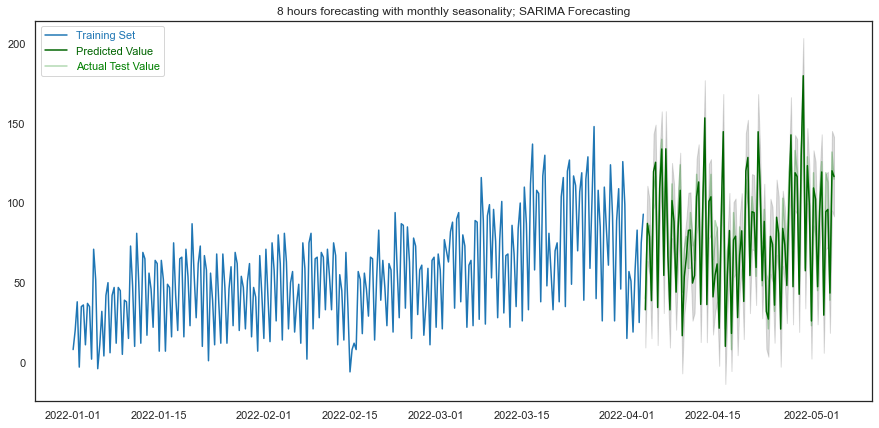

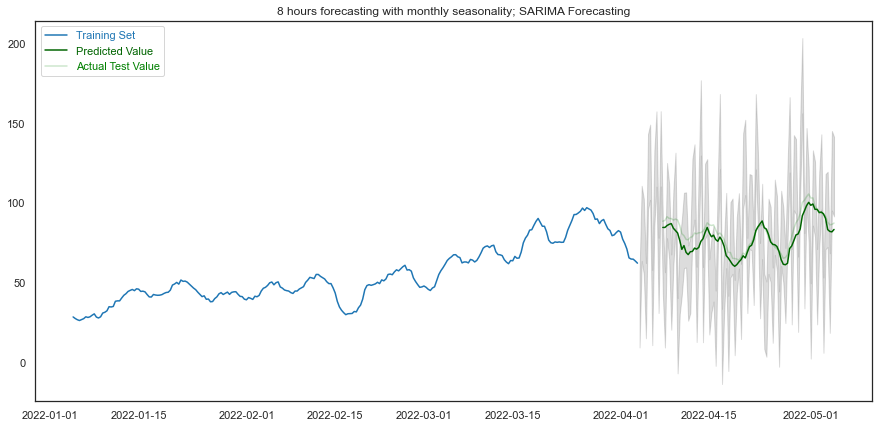

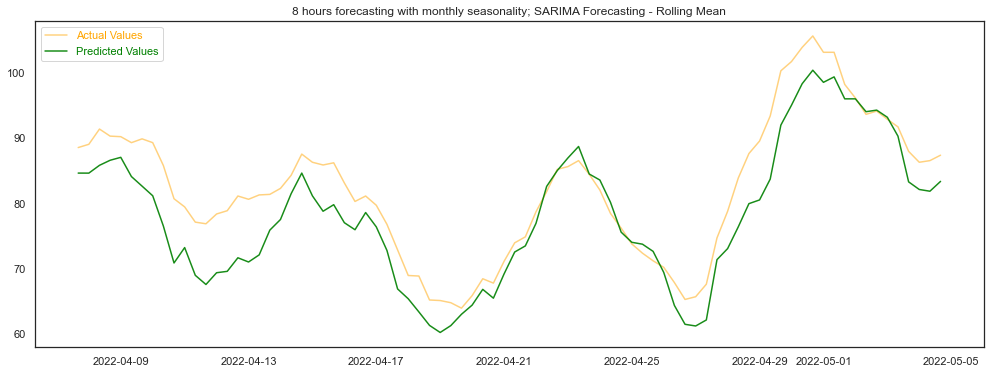

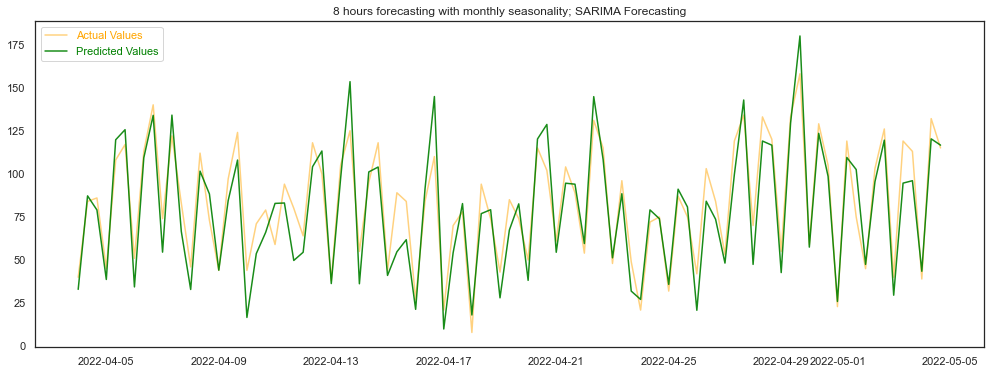

In [44]:
fitted_series = forecast(SARIMA_model_M, test8H, train8H, '8H', avg, sd, '8 hours forecasting with monthly seasonality; SARIMA')

In [45]:
metricsSarima8HMontly = { 'MSE' : mean_squared_error(test8H.trips_count, fitted_series), 
'MAE' : mean_absolute_error(test8H.trips_count, fitted_series), 
'MAPE' : mean_absolute_percentage_error(test8H.trips_count, fitted_series), 
'SMAPE' : smape(test8H.trips_count, fitted_series) }
metricsSarima8HMontly

{'MSE': 196.37728066747493,
 'MAE': 11.616749559000592,
 'MAPE': 0.17028644653292196,
 'SMAPE': 17.985737885953878}

Weekly seasonality

In [46]:
df8H = temporal_aggregation(df = df, aggr_freq = '8H')
# select only data of 2022 for computational reasons
df8H = df8H[df8H.index.year == 2022]
# drop column non-significant according to SARIMA_model summary
df8H = df8H.drop(['finantial', 'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'holiday', 'day'], axis=1)
# split train-test
train8H = df8H[df8H.index < pd.Timestamp('2022-04-04 00:00:00')] # only one month for test (last day availanle 2022-05-04)
test8H = df8H[df8H.index >= pd.Timestamp('2022-04-04 00:00:00')]
# normalize
train8H, test8H, avg, sd = normalize(train8H, test8H)

weekly_m = int((24/aggr_freq) * 7) 

SARIMA_model_W = pm.auto_arima(train8H['trips_count'], 
                    train8H[train8H.columns.drop('trips_count')], 
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None, # order of first-differencing; if None, the value is determined with test below
                    test='adf', # Augmented Dickey-Fuller Test 
                    max_p=3, 
                    max_q=3, 
                    m=weekly_m, 
                    seasonal=True, # SEASONAL VARIATION
                    suppress_warnings=True,
                    stepwise=True 
                )

In [47]:
SARIMA_model_W.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  279
Model:             SARIMAX(2, 0, 1)x(1, 0, 1, 21)   Log Likelihood                 -59.383
Date:                            Fri, 14 Oct 2022   AIC                            154.765
Time:                                    17:26:42   BIC                            220.127
Sample:                                01-01-2022   HQIC                           180.985
                                     - 04-03-2022                                         
Covariance Type:                              opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
leisure                     0.0531      0.020      2.692      0.007       0.014       0.092
public_services             0.0291      0.020      1.478      0.139      -0.009       0.068
building                    0.0711      0.018      3.924      0.000       0.036       0.107
education                   0.0519      0.019      2.740      0.006       0.015       0.089
food                        0.1414      0.023      6.273      0.000       0.097       0.186
transport                   0.1538      0.031      4.949      0.000       0.093       0.215
healthcare                  0.0392      0.020      1.954      0.051      -0.000       0.078
office                      0.0572      0.018      3.206      0.001       0.022       0.092
shop                        0.0883      0.025      3.582      0.000       0.040       0.137
tourism                     0.0649      0.017      3.824      0.000       0.032       0.098
count_bus_multimodality    -0.0237      0.017     -1.419      0.156      -0.056       0.009
precipMM                   -0.0873      0.021     -4.141      0.000      -0.129      -0.046
ar.L1                       0.8663      0.104      8.293      0.000       0.662       1.071
ar.L2                       0.0886      0.091      0.973      0.331      -0.090       0.267
ma.L1                      -0.7249      0.085     -8.558      0.000      -0.891      -0.559
ar.S.L21                    0.9932      0.005    182.544      0.000       0.982       1.004
ma.S.L21                   -0.7709      0.066    -11.754      0.000      -0.899      -0.642
sigma2                      0.0751      0.008      9.822      0.000       0.060       0.090
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 0.29
Prob(Q):                              0.79   Prob(JB):                         0.86
Heteroskedasticity (H):               1.67   Skew:                            -0.06
Prob(H) (two-sided):                  0.01   Kurtosis:                         2.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Error on normalized data:
{'MSE': 0.17082104742613477, 'MAE': 0.3476857000831047, 'MAPE': 1.4825967851749438, 'SMAPE': 49.92580014598455} 

Error on original data:
{'MSE': 172.35443732972237, 'MAE': 11.04402480096438, 'MAPE': 0.18567453807920226, 'SMAPE': 19.21076633187395}


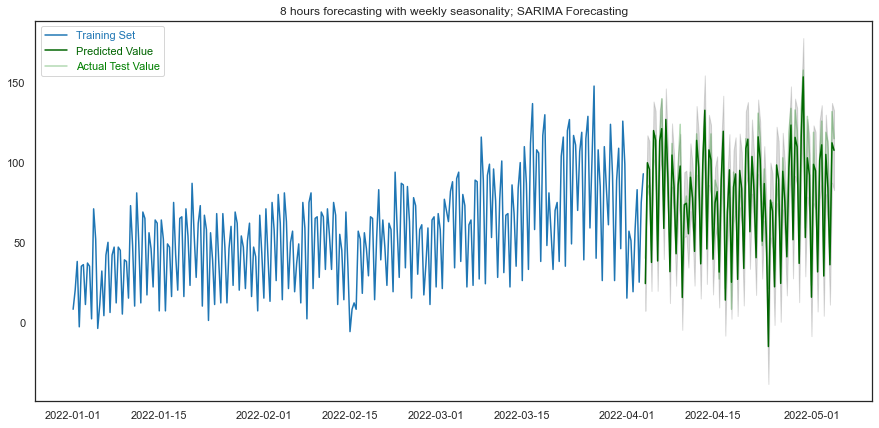

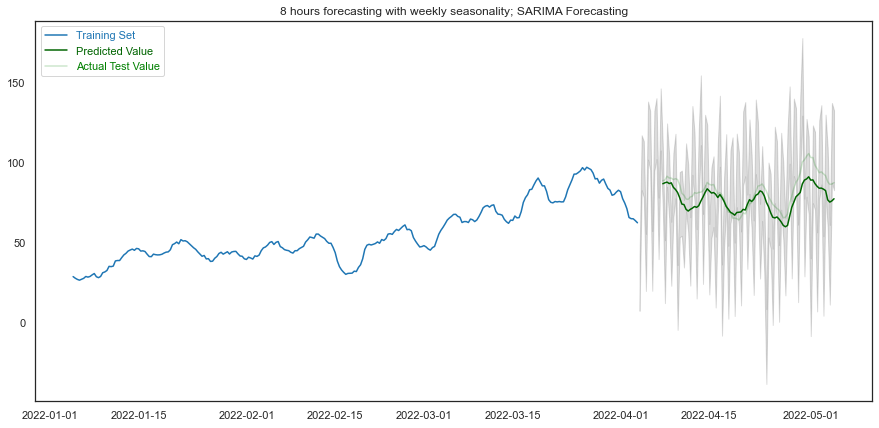

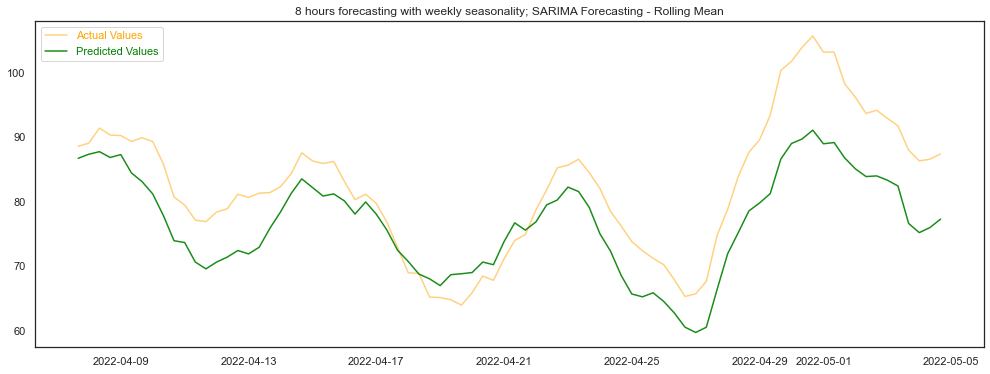

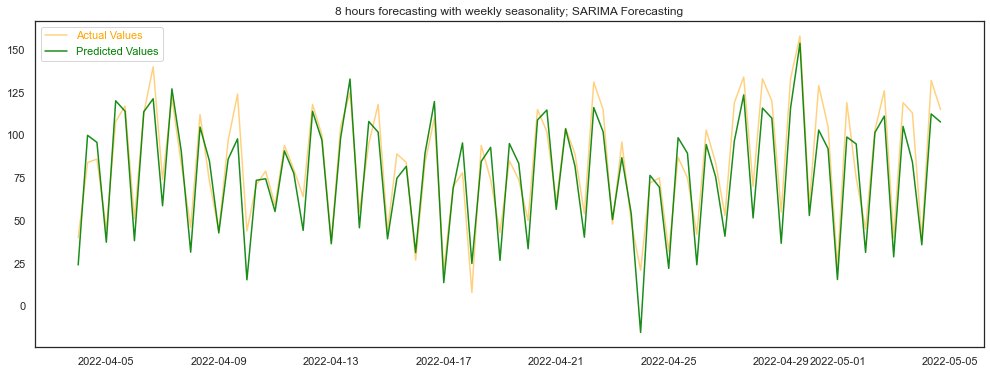

In [48]:
fitted_series = forecast(SARIMA_model_W, test8H, train8H, '8H', avg, sd, '8 hours forecasting with weekly seasonality; SARIMA')

In [49]:
metricsSarima8HWeek = { 'MSE' : mean_squared_error(test8H.trips_count, fitted_series), 
'MAE' : mean_absolute_error(test8H.trips_count, fitted_series), 
'MAPE' : mean_absolute_percentage_error(test8H.trips_count, fitted_series), 
'SMAPE' : smape(test8H.trips_count, fitted_series) }
metricsSarima8HWeek

{'MSE': 172.35443732972237,
 'MAE': 11.04402480096438,
 'MAPE': 0.18567453807920226,
 'SMAPE': 19.21076633187395}

Seasonal cycles

In [ ]:
# df8H = temporal_aggregation(df = df, aggr_freq = '8H')
# # select only data of 2022 for computational reasons
# df8H = df8H[df8H.index.year >= 2021]
# # drop column non-significant according to SARIMA_model summary
# # df8H = df8H.drop([], axis=1)
# # split train-test
# train8H = df8H[df8H.index < pd.Timestamp('2022-04-04 00:00:00')] # only one month for test (last day availanle 2022-05-04)
# test8H = df8H[df8H.index >= pd.Timestamp('2022-04-04 00:00:00')]
# normalize
# train8H, test8H, avg, sd = normalize(train8H, test8H)

# season_m = int((24/aggr_freq) * 90) 

# SARIMA_model_S = pm.auto_arima(train8H['trips_count'], 
#                     train8H[train8H.columns.drop('trips_count')], 
#                     start_p=2, # starting number of lags (AR part) -> from PACF
#                     start_q=0, # the order of moving average (MA part) -> from ACF
#                     d=None, # order of first-differencing; if None, the value is determined with test below
#                     test='adf', # Augmented Dickey-Fuller Test 
#                     max_p=3, 
#                     max_q=3, 
#                     m=season_m, 
#                     seasonal=True, # SEASONAL VARIATION
#                     suppress_warnings=True,
#                     stepwise=True 
#                 )

# SARIMA_model_S.summary()

In [ ]:
# fitted_series = forecast(SARIMA_model_S, test8H, train8H, '8H', avg, sd, 'SARIMA')

In [ ]:
# metricsSarima8HSeason = { 'MSE' : mean_squared_error(test8H.trips_count, fitted_series), 
# 'MAE' : mean_absolute_error(test8H.trips_count, fitted_series), 
# 'MAPE' : mean_absolute_percentage_error(test8H.trips_count, fitted_series), 
# 'SMAPE' : smape(test8H.trips_count, fitted_series) }
# metricsSarima8HSeason

#### Daily prediction with weekly seasonality

In [50]:
df_D = temporal_aggregation(df = df, aggr_freq = 'D')
# select only data of 2022 for computational reasons
df_D = df_D[df_D.index.year == 2022]
# drop column non-significant according to SARIMA_model summary
df_D = df_D.drop(['finantial', 'totalSnow_cm', 'windspeedKmph', 'tempC', 'visibility', 'holiday', 'day'], axis=1)
# split train-test
trainD = df_D[df_D.index < pd.Timestamp('2022-04-04 00:00:00')] # only one month for test (last day availanle 2022-05-04)
testD = df_D[df_D.index >= pd.Timestamp('2022-04-04 00:00:00')]
# normalize
trainD, testD, avg, sd = normalize(trainD, testD)


weekly_m = int((24/aggr_freq) * 7) 

SARIMA_model_W_daily = pm.auto_arima(trainD['trips_count'], 
                    trainD[trainD.columns.drop('trips_count')], 
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None, # order of first-differencing; if None, the value is determined with test below
                    test='adf', # Augmented Dickey-Fuller Test 
                    max_p=3, 
                    max_q=3, 
                    m=weekly_m, 
                    seasonal=True, # SEASONAL VARIATION
                    suppress_warnings=True,
                    stepwise=True 
                )

In [51]:
SARIMA_model_W_daily.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                   93
Model:             SARIMAX(1, 0, 2)x(1, 0, [], 21)   Log Likelihood                 -14.947
Date:                             Fri, 14 Oct 2022   AIC                             63.894
Time:                                     18:08:31   BIC                            106.948
Sample:                                 01-01-2022   HQIC                            81.278
                                      - 04-03-2022                                         
Covariance Type:                               opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
leisure                     0.0585      0.051      1.147      0.252      -0.042       0.159
public_services            -0.0231      0.049     -0.468      0.640      -0.120       0.074
building                    0.0366      0.038      0.970      0.332      -0.037       0.111
education                   0.0527      0.040      1.331      0.183      -0.025       0.130
food                        0.1799      0.067      2.673      0.008       0.048       0.312
transport                   0.2699      0.070      3.835      0.000       0.132       0.408
healthcare                  0.0386      0.052      0.739      0.460      -0.064       0.141
office                      0.0481      0.030      1.596      0.110      -0.011       0.107
shop                        0.0676      0.069      0.980      0.327      -0.068       0.203
tourism                     0.0256      0.038      0.667      0.505      -0.050       0.101
count_bus_multimodality     0.0081      0.035      0.230      0.818      -0.061       0.077
precipMM                   -0.1705      0.038     -4.465      0.000      -0.245      -0.096
ar.L1                       0.9900      0.019     52.705      0.000       0.953       1.027
ma.L1                      -0.5719      0.141     -4.047      0.000      -0.849      -0.295
ma.L2                      -0.2133      0.138     -1.550      0.121      -0.483       0.056
ar.S.L21                    0.3625      0.122      2.970      0.003       0.123       0.602
sigma2                      0.0765      0.016      4.712      0.000       0.045       0.108
===================================================================================
Ljung-Box (L1) (Q):                   0.14   Jarque-Bera (JB):                 1.39
Prob(Q):                              0.70   Prob(JB):                         0.50
Heteroskedasticity (H):               2.03   Skew:                             0.17
Prob(H) (two-sided):                  0.05   Kurtosis:                         2.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

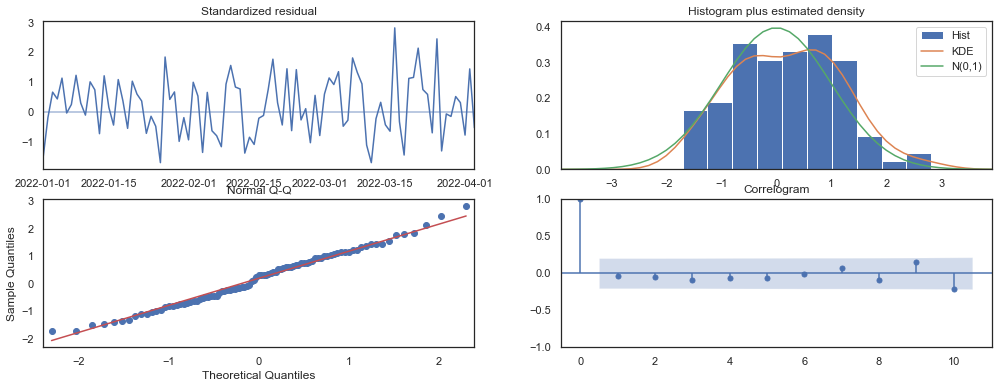

In [52]:
SARIMA_model_W_daily.plot_diagnostics()
plt.show()

Error on normalized data:
{'MSE': 0.19944124321920045, 'MAE': 0.3639703041056655, 'MAPE': 0.8236528285658608, 'SMAPE': 39.078209633934556} 

Error on original data:
{'MSE': 725.8934444160244, 'MAE': 21.958107268231366, 'MAPE': 0.09206650552552417, 'SMAPE': 9.376220163128254}


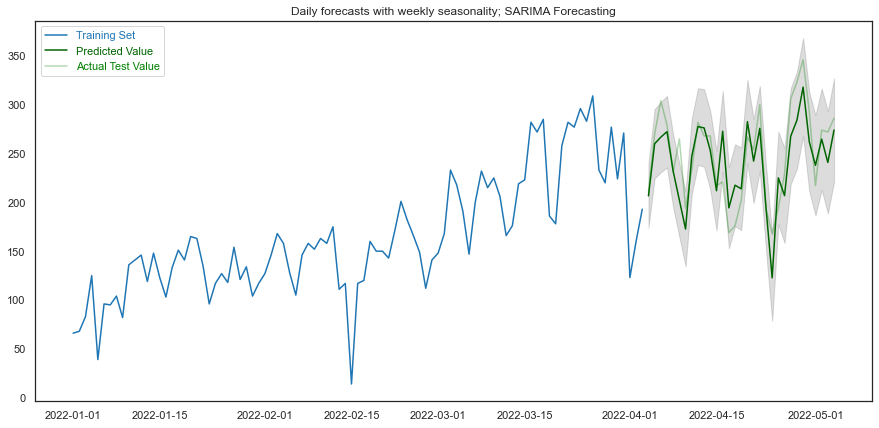

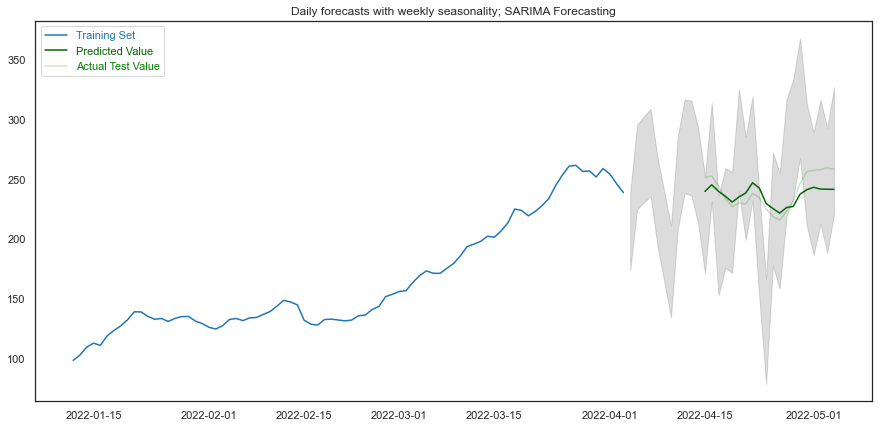

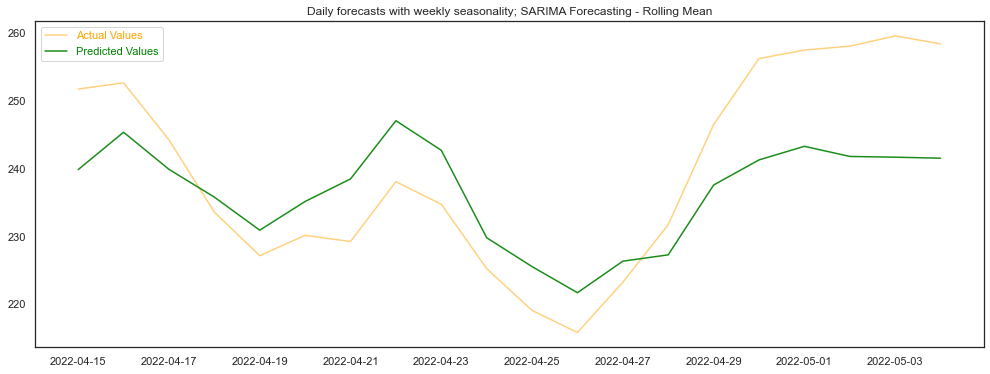

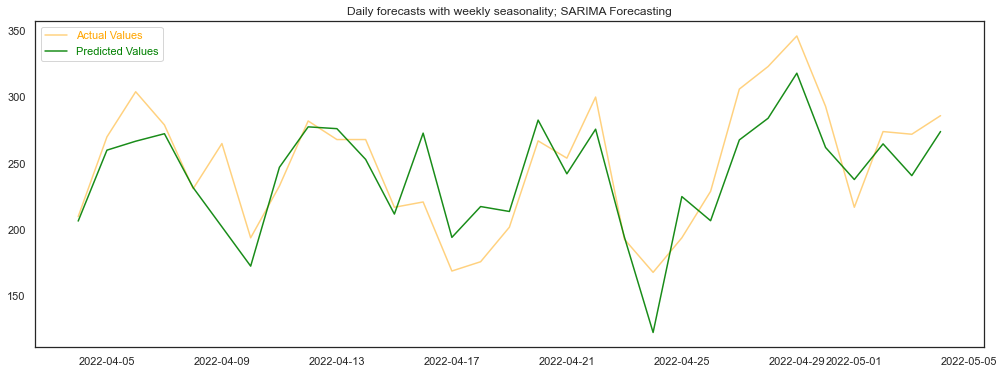

In [53]:
fitted_series = forecast(SARIMA_model_W_daily, testD, trainD, 'D', avg, sd, 'Daily forecasts with weekly seasonality; SARIMA')

In [54]:
metricsSarimaDWeek = { 'MSE' : mean_squared_error(testD.trips_count, fitted_series), 
'MAE' : mean_absolute_error(testD.trips_count, fitted_series), 
'MAPE' : mean_absolute_percentage_error(testD.trips_count, fitted_series), 
'SMAPE' : smape(testD.trips_count, fitted_series) }
metricsSarimaDWeek
# no MAE improvement with respect to daily ARIMA (without seasonality) 

{'MSE': 725.8934444160244,
 'MAE': 21.958107268231366,
 'MAPE': 0.09206650552552417,
 'SMAPE': 9.376220163128254}

#### Hourly prediction with seasonality

In [57]:
dfH = temporal_aggregation(df = df, aggr_freq = 'H')
# select only data of 2022 for computational reasons
dfH = dfH[dfH.index.year == 2022]
# drop column non-significant according to SARIMA_model summary
dfH = dfH.drop(['count_bus_multimodality', 'totalSnow_cm', 'precipMM', 'visibility', 'holiday', 'day'], axis=1)
# split train-test
trainH = dfH[dfH.index < pd.Timestamp('2022-04-04 00:00:00')] # only one month for test (last day availanle 2022-05-04)
testH = dfH[dfH.index >= pd.Timestamp('2022-04-04 00:00:00')]
# normalize
trainH, testH, avg, sd = normalize(trainH, testH)

weekly_m = int((24/aggr_freq) * 7) 

SARIMA_model_HW = pm.auto_arima(trainH['trips_count'], 
                    trainH[trainH.columns.drop('trips_count')], 
                    start_p=2, # starting number of lags (AR part) -> from PACF
                    start_q=0, # the order of moving average (MA part) -> from ACF
                    d=None, # order of first-differencing; if None, the value is determined with test below
                    test='adf', # Augmented Dickey-Fuller Test 
                    max_p=3, 
                    max_q=3, 
                    m=weekly_m, 
                    seasonal=True, # SEASONAL VARIATION
                    suppress_warnings=True,
                    stepwise=True 
                )

In [58]:
SARIMA_model_HW.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                 2232
Model:             SARIMAX(2, 0, 0)x(2, 0, [1], 21)   Log Likelihood               -1808.744
Date:                              Fri, 14 Oct 2022   AIC                           3667.488
Time:                                      19:26:29   BIC                           3810.255
Sample:                                  01-01-2022   HQIC                          3719.619
                                       - 04-03-2022                                         
Covariance Type:                                opg                                         
===========================================================================================
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
leisure                     0.1106      0.010     11.132      0.000       0.091       0.130
public_services             0.0658      0.009      7.064      0.000       0.048       0.084
building                    0.0870      0.011      8.182      0.000       0.066       0.108
education                   0.1045      0.011      9.603      0.000       0.083       0.126
food                        0.0981      0.012      8.382      0.000       0.075       0.121
transport                   0.2345      0.012     19.977      0.000       0.212       0.258
finantial                   0.0235      0.010      2.450      0.014       0.005       0.042
healthcare                  0.0456      0.008      5.532      0.000       0.029       0.062
office                      0.0795      0.009      8.698      0.000       0.062       0.097
shop                        0.1217      0.012     10.011      0.000       0.098       0.146
tourism                     0.0609      0.008      7.267      0.000       0.044       0.077
count_bus_multimodality    -0.0007      0.013     -0.051      0.960      -0.026       0.025
totalSnow_cm                0.0320      0.027      1.182      0.237      -0.021       0.085
windspeedKmph               0.0633      0.024      2.616      0.009       0.016       0.111
tempC                       0.1597      0.024      6.661      0.000       0.113       0.207
visibility                  0.0020      0.021      0.095      0.924      -0.040       0.044
precipMM                   -0.0152      0.025     -0.613      0.540      -0.064       0.033
holiday                    -0.0335      0.025     -1.323      0.186      -0.083       0.016
day                         0.0106      0.027      0.400      0.689      -0.041       0.063
ar.L1                       0.3522      0.021     16.412      0.000       0.310       0.394
ar.L2                       0.2275      0.021     10.898      0.000       0.187       0.268
ar.S.L21                    0.7215      0.139      5.191      0.000       0.449       0.994
ar.S.L42                   -0.0934      0.022     -4.268      0.000      -0.136      -0.051
ma.S.L21                   -0.6768      0.138     -4.896      0.000      -0.948      -0.406
sigma2                      0.2960      0.008     35.237      0.000       0.279       0.312
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                50.30
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.55   Skew:                             0.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.35
===================================================================================

Warnings:
[1] Covariance matrix ca

Error on normalized data:
{'MSE': 0.5696296515142906, 'MAE': 0.586447751365884, 'MAPE': 0.8613100905946574, 'SMAPE': 83.86693909314761} 

Error on original data:
{'MSE': 17.906104187833623, 'MAE': 3.2880134466974904, 'MAPE': 0.7884415836724107, 'SMAPE': 43.912052062830334}


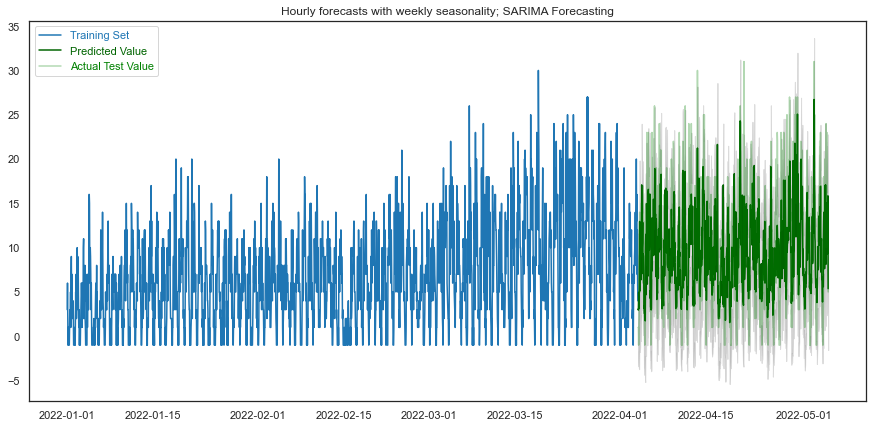

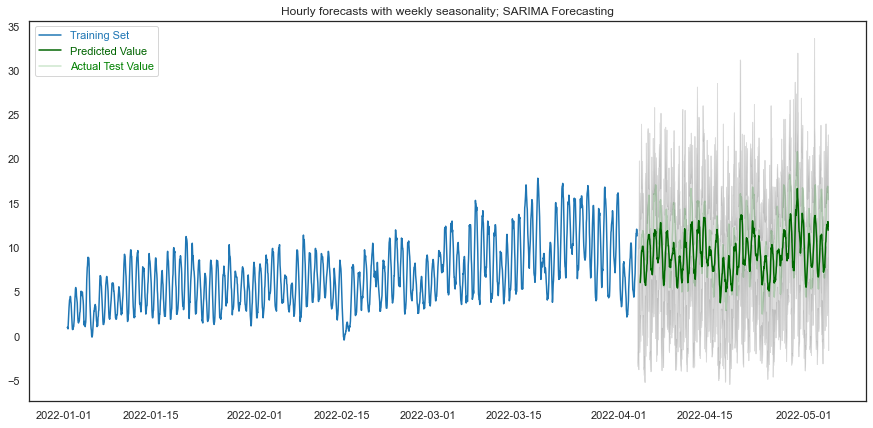

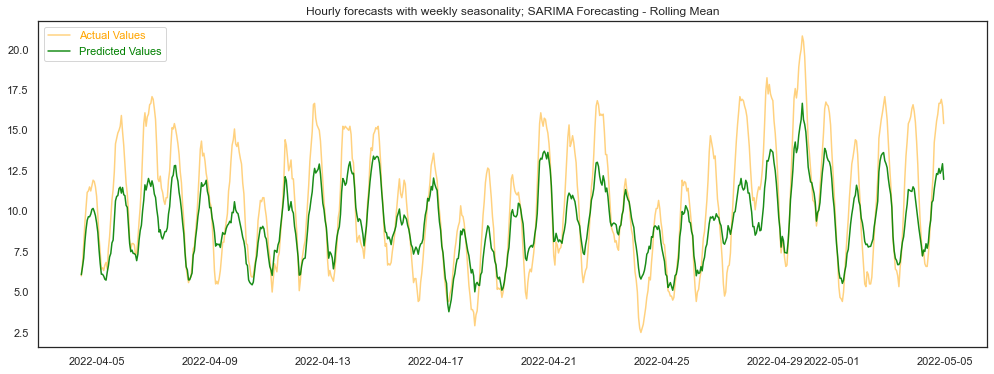

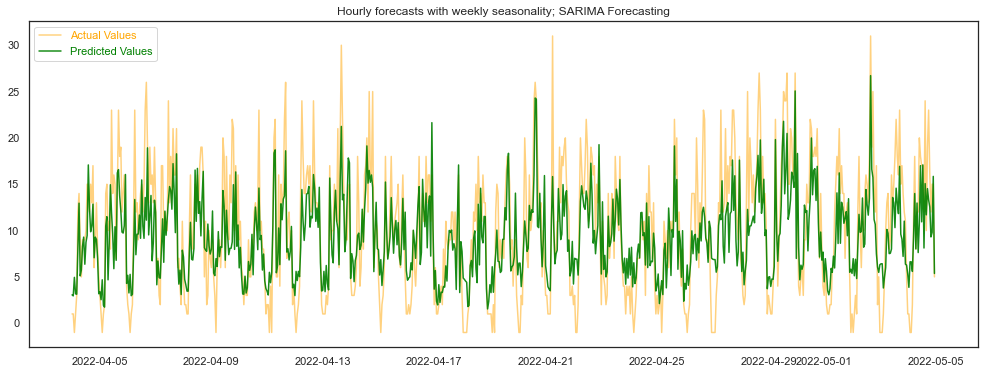

In [59]:
fitted_series = forecast(SARIMA_model_HW, testH, trainH, 'H', avg, sd, 'Hourly forecasts with weekly seasonality; SARIMA')

#### Compare models
In order to compare models with different time series frequencies, it is necessary to use scale independent measures, such as MAPE and SMAPE.

In [55]:
def print_metric(metric):
    print(metric, ':\n',
    'ARIMA 1H', metricsH[metric], '\n',
    'ARIMA 4H', metrics4H[metric], '\n',
    'ARIMA 8H', metrics8H[metric], '\n',
    'ARIMA daily', metrics_daily[metric], '\n',
    'SARIMA 8H-weekly:', metricsSarima8HWeek[metric], '\n',
    'SARIMA 8H-monthly:', metricsSarima8HMontly[metric]
    #'SARIMA 8H-3months:', metricsSarima8HSeason[metric]
    )

print_metric('MAPE')
print('\n')
print_metric('SMAPE')

MAPE :
 ARIMA 1H 0.5789753729023945 
 ARIMA 4H 1089784138673477.9 
 ARIMA 8H 0.1941292879840476 
 ARIMA daily 0.08415545871038504 
 SARIMA 8H-weekly: 0.18567453807920226 
 SARIMA 8H-monthly: 0.17028644653292196


SMAPE :
 ARIMA 1H 50.205282926404344 
 ARIMA 4H 26.935052621221214 
 ARIMA 8H 20.243935390849852 
 ARIMA daily 8.798273585133655 
 SARIMA 8H-weekly: 19.21076633187395 
 SARIMA 8H-monthly: 17.985737885953878


Model perfomances, SMAPE comparisons:
1) SARIMA (data at 8 hours intervals, monthly seasonality)
2) SARIMA (data at 8 hours intervals, weekly seasonality)
3) ARIMA (daily data)
4) ARIMA (data at 8 hours intervals)
5) ARIMA (data at 4 hours intervals)
6) ARIMA (data at 1 hours intervals)

#### Limitations

Although statistical methods suited for timeseries as ARIMA can capture really well temporal dependencies, they cannot incorporate the spatial aspect in the prediction.
